In [22]:
import pandas as pd 
import numpy as np 

df = pd.read_csv("testdata.csv", sep="\t")
df.shape

(813, 5)

In [23]:
df.head()

,id,DSS,day,bwc,vwr
0,SvBi029,1,0,100.0,79.3
1,SvBi029,1,1,103.5,125.4
2,SvBi029,1,2,102.6,95.8
3,SvBi029,1,3,100.9,57.1
4,SvBi029,1,4,101.3,69.7


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 813 entries, 0 to 812
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      813 non-null    object 
 1   DSS     813 non-null    int64  
 2   day     813 non-null    int64  
 3   bwc     813 non-null    float64
 4   vwr     813 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 31.9+ KB


In [25]:
active_animals = df.groupby(['day', 'DSS'])['id'].nunique().unstack(level='DSS')

print("Anzahl der aktiven Tiere im Zeitverlauf:")
display(active_animals)

survival_rate = active_animals.div(active_animals.loc[0]) * 100
print("\nÜberlebensrate (in %) relativ zum Starttag 0:")
display(survival_rate.round(1))


Anzahl der aktiven Tiere im Zeitverlauf:


DSS,0,1,2
day,,,
0,23,22,17
1,23,22,17
2,23,22,17
3,23,22,17
4,23,22,17
5,23,22,17
6,23,21,17
7,23,21,15
8,23,19,14



Überlebensrate (in %) relativ zum Starttag 0:


DSS,0,1,2
day,,,
0,100.0,100.0,100.0
1,100.0,100.0,100.0
2,100.0,100.0,100.0
3,100.0,100.0,100.0
4,100.0,100.0,100.0
5,100.0,100.0,100.0
6,100.0,95.5,100.0
7,100.0,95.5,88.2
8,100.0,86.4,82.4


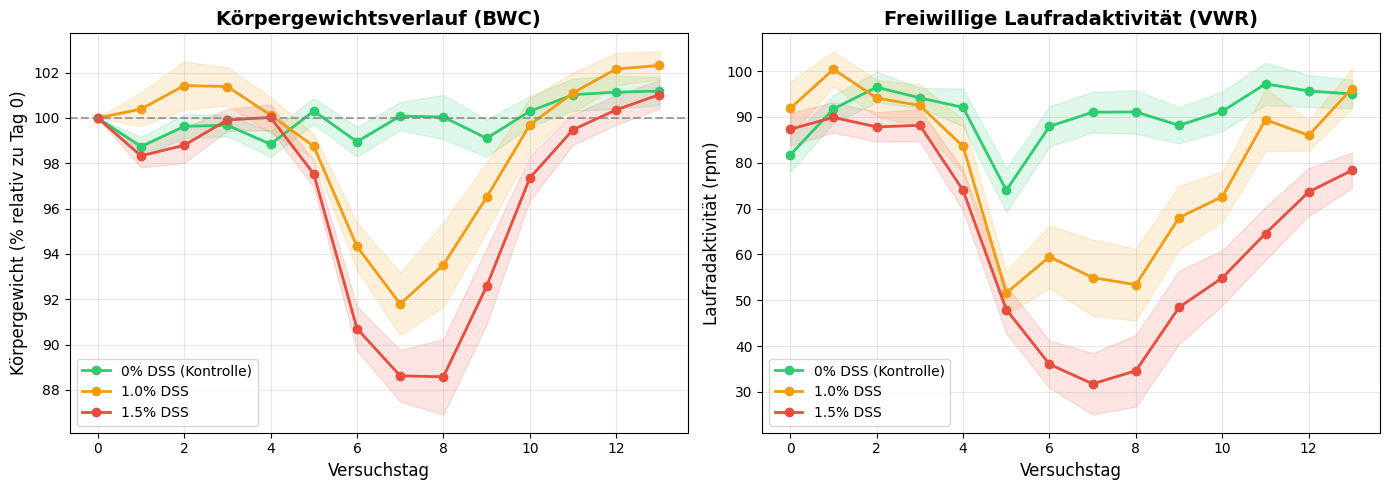

In [26]:
import matplotlib.pyplot as plt

# Daten gruppieren: Mittelwert und Standardfehler pro Dosis und Tag
grouped = df.groupby(['DSS', 'day']).agg(
    bwc_mean=('bwc', 'mean'),
    bwc_sem=('bwc', 'sem'),
    vwr_mean=('vwr', 'mean'),
    vwr_sem=('vwr', 'sem')
).reset_index()

# Zwei Diagramme nebeneinander erstellen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
labels = {0: '0% DSS (Kontrolle)', 1: '1.0% DSS', 2: '1.5% DSS'}

# Linkes Diagramm: Gewichtsverlauf
for dss in [0, 1, 2]:
    data = grouped[grouped['DSS'] == dss]
    ax1.plot(data['day'], data['bwc_mean'], 'o-', color=colors[dss], label=labels[dss], linewidth=2)
    ax1.fill_between(data['day'],
                     data['bwc_mean'] - data['bwc_sem'],
                     data['bwc_mean'] + data['bwc_sem'],
                     color=colors[dss], alpha=0.15)

ax1.axhline(100, color='gray', linestyle='--', alpha=0.7)
ax1.set_xlabel('Versuchstag', fontsize=12)
ax1.set_ylabel('Körpergewicht (% relativ zu Tag 0)', fontsize=12)
ax1.set_title('Körpergewichtsverlauf (BWC)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Rechtes Diagramm: Laufradaktivität
for dss in [0, 1, 2]:
    data = grouped[grouped['DSS'] == dss]
    ax2.plot(data['day'], data['vwr_mean'], 'o-', color=colors[dss], label=labels[dss], linewidth=2)
    ax2.fill_between(data['day'],
                     data['vwr_mean'] - data['vwr_sem'],
                     data['vwr_mean'] + data['vwr_sem'],
                     color=colors[dss], alpha=0.15)

ax2.set_xlabel('Versuchstag', fontsize=12)
ax2.set_ylabel('Laufradaktivität (rpm)', fontsize=12)
ax2.set_title('Freiwillige Laufradaktivität (VWR)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [28]:
from scipy import stats

test_days = [0, 8, 13]

for day in test_days:
    day_data = df[df['day'] == day]
    
    group_0 = day_data[day_data['DSS'] == 0]
    group_1 = day_data[day_data['DSS'] == 1]
    group_2 = day_data[day_data['DSS'] == 2]
    
    print(f"=== Tag {day} ===")
    
    for var in ['bwc', 'vwr']:
        try:
            h, p = stats.kruskal(group_0[var], group_1[var], group_2[var])
            sig = "*** SIGNIFIKANT" if p < 0.05 else "nicht signifikant"
            print(f"  {var.upper()}: H = {h:.2f}, p = {p:.6f}  → {sig}")
        except ValueError:
            print(f"  {var.upper()}: Alle Werte identisch – kein Test möglich (erwartetes Ergebnis)")
    
    print()


=== Tag 0 ===
  BWC: Alle Werte identisch – kein Test möglich (erwartetes Ergebnis)
  VWR: H = 3.63, p = 0.162902  → nicht signifikant

=== Tag 8 ===
  BWC: H = 18.78, p = 0.000084  → *** SIGNIFIKANT
  VWR: H = 23.17, p = 0.000009  → *** SIGNIFIKANT

=== Tag 13 ===
  BWC: H = 2.32, p = 0.313601  → nicht signifikant
  VWR: H = 9.15, p = 0.010326  → *** SIGNIFIKANT



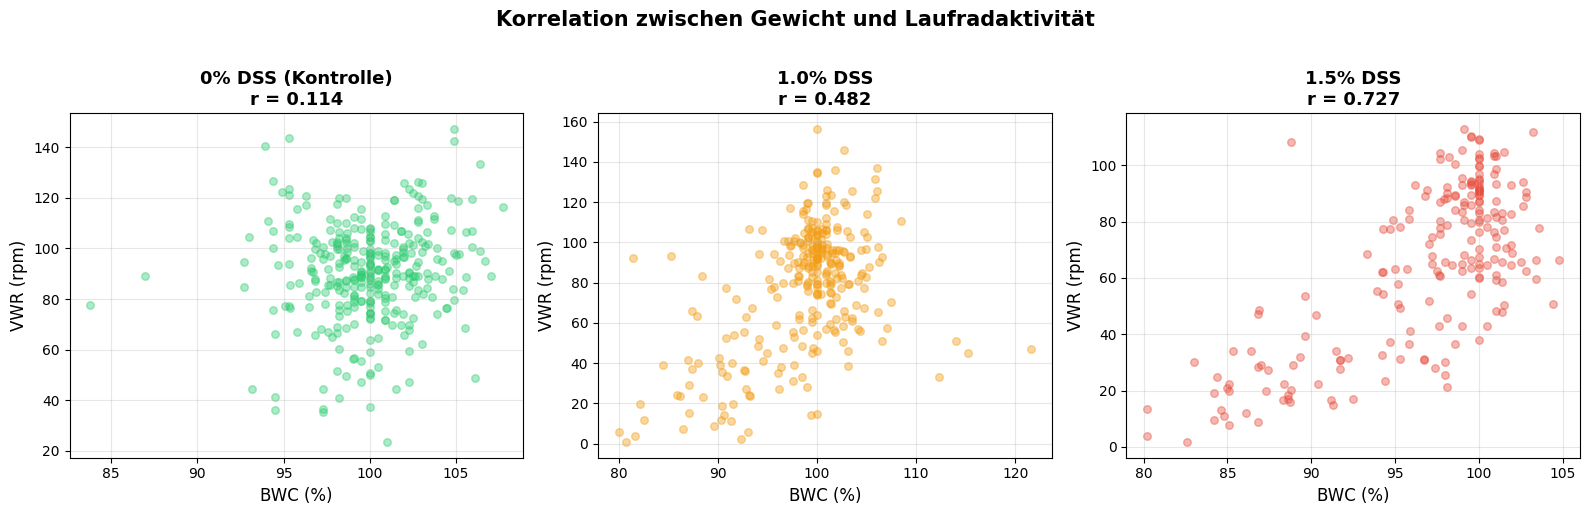

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, dss in enumerate([0, 1, 2]):
    subset = df[df['DSS'] == dss]
    
    r = subset['bwc'].corr(subset['vwr'])
    
    axes[i].scatter(subset['bwc'], subset['vwr'], 
                    color=colors[dss], alpha=0.4, s=30)
    axes[i].set_xlabel('BWC (%)', fontsize=12)
    axes[i].set_ylabel('VWR (rpm)', fontsize=12)
    axes[i].set_title(f'{labels[dss]}\nr = {r:.3f}', fontsize=13, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Korrelation zwischen Gewicht und Laufradaktivität', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
